In [ ]:
!pip install pandas pubchempy
!pip install chembl_webresource_client
!pip install rdkit

  Preparing metadata (setup.py) ... done
  Created wheel for pubchempy: filename=PubChemPy-1.0.4-py3-none-any.whl size=13818 sha256=dd8cc0396da8c5d09e83b06e90fc3581558c667d5a287e22de4a6f043bbcef8c
  Stored in directory: /root/.cache/pip/wheels/8b/e3/6c/3385b2db08b0985a87f5b117f98d0cb61a3ae3ca3bcbbd8307
Successfully built pubchempy
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 62.1 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem
import pandas as pd
from chembl_webresource_client.new_client import new_client
import numpy as np
from IPython.display import display
from rdkit.Chem import Draw

In [ ]:
def get_canonical_smiles(smi):
  try:
    return Chem.MolToSmiles(Chem.MolFromSmiles(smi), canonical=True)
  except:
    print(f"Failured to converting {smi} into canonical format")
    return None

In [ ]:
trainPath = "/content/train.csv"
testPath = "/content/test.csv"

df_train = pd.read_csv(trainPath)
df_test = pd.read_csv(testPath)
print(df_train.columns)
df_train["Canonical"] = df_train["Canonical_Smiles"].apply(get_canonical_smiles)
df_train.isna().sum()

Index(['ID', 'Canonical_Smiles', 'Inhibition'], dtype='object')


,0
ID,0
Canonical_Smiles,0
Inhibition,0
Canonical,0


In [ ]:
df_train.head()

,ID,Canonical_Smiles,Inhibition,Canonical
0,TRAIN_0000,Cl.OC1(Cc2cccc(Br)c2)CCNCC1,12.50,Cl.OC1(Cc2cccc(Br)c2)CCNCC1
1,TRAIN_0001,Brc1ccc2OCCc3ccnc1c23,4.45,Brc1ccc2c3c(ccnc13)CCO2
2,TRAIN_0002,CC1(CO)CC(=NO1)c2cc(c(F)cc2Cl)[N+](=O)[O-],4.92,CC1(CO)CC(c2cc([N+](=O)[O-])c(F)cc2Cl)=NO1
3,TRAIN_0003,Fc1ccc2nc(Nc3cccc(COc4cccc(c4)C(=O)N5CCOCC5)c3...,71.50,O=C(c1cccc(OCc2cccc(Nc3nc4ccc(F)cc4[nH]3)c2)c1...
4,TRAIN_0004,CC(C)CC(=O)C1=C(Nc2c(Cl)ccc(Cl)c2C1=O)S(=O)C,18.30,CC(C)CC(=O)c1c(S(C)=O)[nH]c2c(Cl)ccc(Cl)c2c1=O


In [ ]:
df_test.head()

,ID,Canonical_Smiles
0,TEST_000,O=C(NC1CCCC1)C2(CCCCC2)N(CC3CCCO3)C(=O)C4=CNC(...
1,TEST_001,CC(C)c1oc(Cn2ccnc2c3cncc(Br)c3)nc1
2,TEST_002,CC1=C(C(=O)NC(=O)N1)S(=O)(=O)NCC(Cc2ccccc2F)c3...
3,TEST_003,Cl.Cn1cc(cn1)c2cc(CN3CCc4nc[nH]c4C35CCOCC5)on2
4,TEST_004,CC(C)OC(=O)c1ccc(cc1)N2CC(CC2=O)C(=O)OCc3ccc(B...


In [ ]:
df_train[df_train["Inhibition"] > 0].describe()

,Inhibition
count,1583.000000
mean,35.278520
std,25.842961
min,0.014700
25%,13.564499
50%,31.400000
75%,52.000000
max,99.381547


In [ ]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

activity = new_client.activity
chembl_id = 'CHEMBL340'
res_discover = activity.filter(target_chembl_id=chembl_id, standard_type="IC50")

# Convert the single record to a DataFrame
df_discover = pd.DataFrame(res_discover[0])
all_columns = df_discover.columns.tolist()

print("\nSuccess! Here is the complete list of available columns for an 'activity' record:")
print(all_columns)


Success! Here is the complete list of available columns for an 'activity' record:
['action_type', 'activity_comment', 'activity_id', 'activity_properties', 'assay_chembl_id', 'assay_description', 'assay_type', 'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint', 'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment', 'data_validity_description', 'document_chembl_id', 'document_journal', 'document_year', 'ligand_efficiency', 'molecule_chembl_id', 'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value', 'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id', 'standard_flag', 'standard_relation', 'standard_text_value', 'standard_type', 'standard_units', 'standard_upper_value', 'standard_value', 'target_chembl_id', 'target_organism', 'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type', 'units', 'uo_units', 'upper_value', 'value']


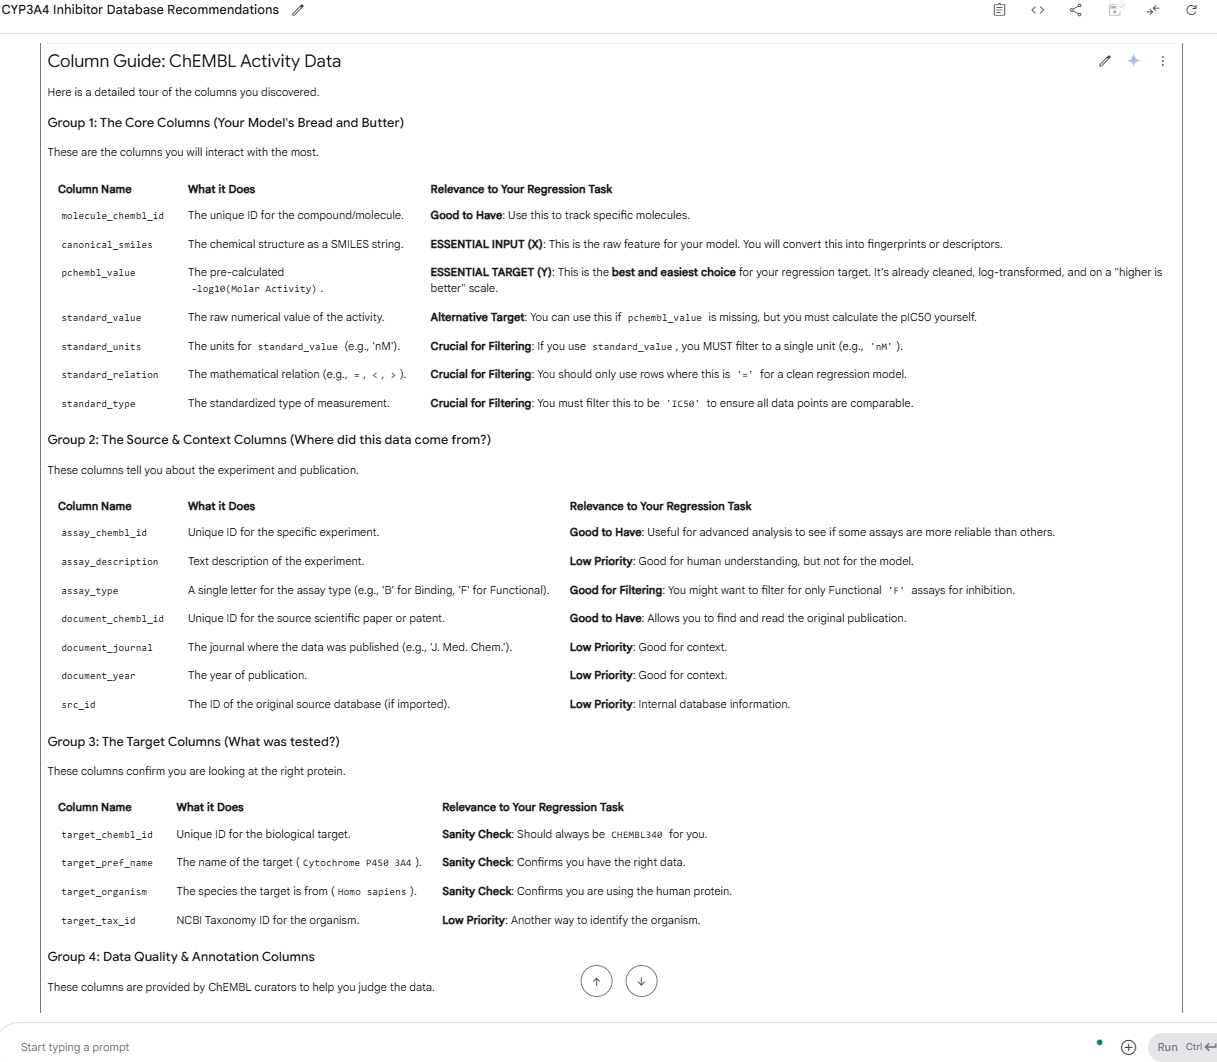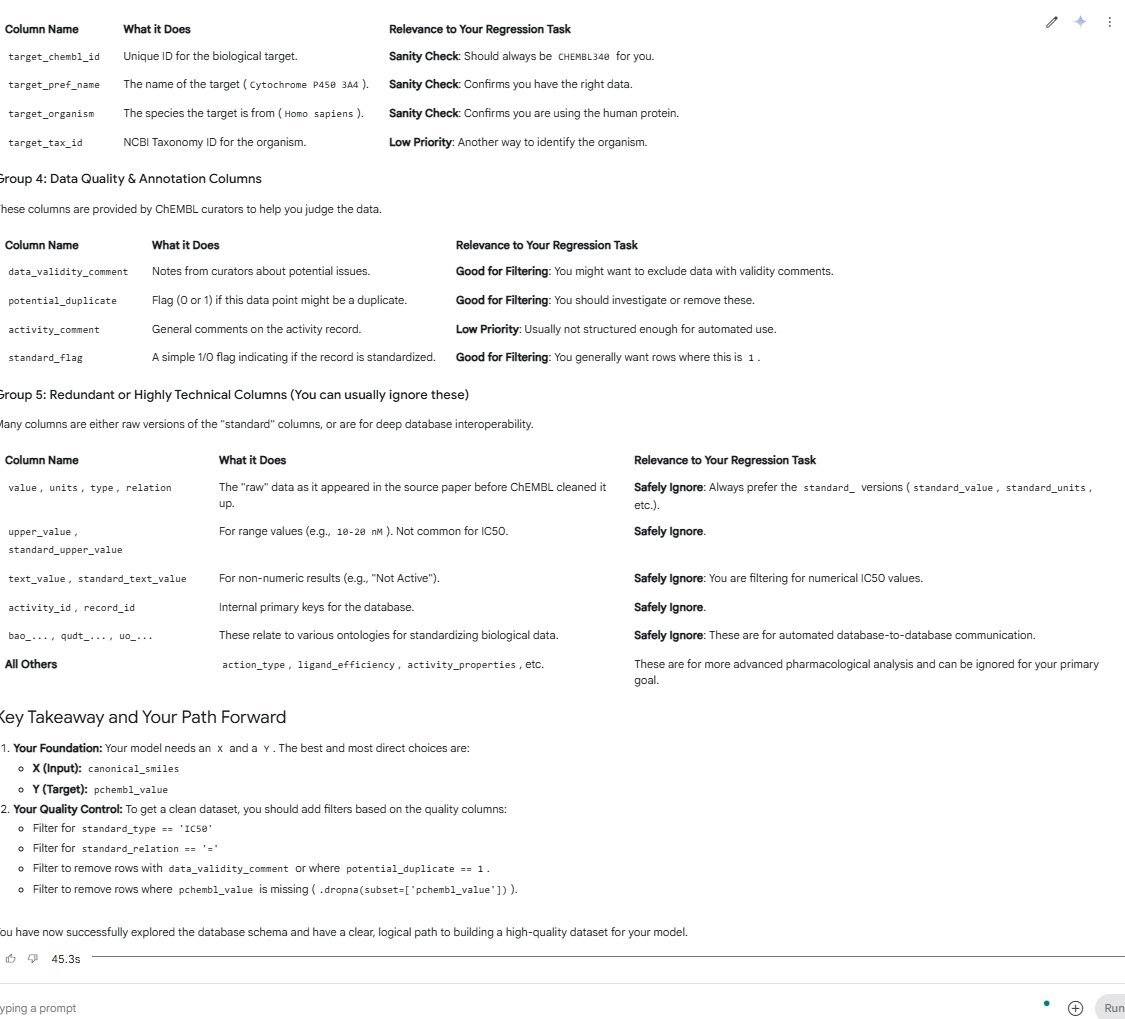

In [ ]:
#['action_type', 'activity_comment', 'activity_id', 'activity_properties',
# 'assay_chembl_id', 'assay_description', 'assay_type', 'assay_variant_accession',
# 'assay_variant_mutation', 'bao_endpoint', 'bao_format', 'bao_label', 'canonical_smiles',
# 'data_validity_comment', 'data_validity_description', 'document_chembl_id', 'document_journal',
# 'document_year', 'ligand_efficiency', 'molecule_chembl_id', 'molecule_pref_name',
# 'parent_molecule_chembl_id', 'pchembl_value', 'potential_duplicate', 'qudt_units',
# 'record_id', 'relation', 'src_id', 'standard_flag', 'standard_relation', 'standard_text_value',
# 'standard_type', 'standard_units', 'standamrd_upper_value', 'standard_value',
# 'target_chembl_id', 'target_organism', 'target_pref_name', 'target_tax_id',
# 'text_value', 'toid', 'type', 'units', 'uo_units', 'upper_value', 'value']


import pandas as pd
from chembl_webresource_client.new_client import new_client
from IPython.display import display

desired_columns = [
    'molecule_chembl_id',
    'canonical_smiles',
    'pchembl_value',
    "standard_value",
    'standard_units',
    "units",
    "assay_chembl_id",
    "assay_description",
    # "assay_type",
]

activity = new_client.activity
chembl_id = 'CHEMBL340' # Target: CYP3A4
res = activity.filter(
    target_chembl_id = chembl_id,
    standard_type = "IC50",
    target_organism = 'Homo sapiens', # Explicitly ask for the human protein
    standard_relation = "=",
).only(
    *desired_columns
)

df = pd.DataFrame(res)
display(df.head())
print(len(df))

,assay_chembl_id,assay_description,canonical_smiles,molecule_chembl_id,pchembl_value,standard_units,standard_value,units,value
0,CHEMBL665756,Inhibition of cytochrome P450 3A4 of isolated ...,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4cccc(-c5ccc...,CHEMBL152968,4.43,nM,37000.0,uM,37.0
1,CHEMBL666254,Inhibition of human cytochrome P450 3A4 as tot...,COc1ccc(NS(=O)(=O)c2ccc(Br)cc2)cc1N1CCN(C)CC1,CHEMBL292759,5.22,nM,6000.0,uM,6.0
2,CHEMBL665756,Inhibition of cytochrome P450 3A4 of isolated ...,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(-c5cccc...,CHEMBL153741,5.10,nM,7900.0,uM,7.9
3,CHEMBL665756,Inhibition of cytochrome P450 3A4 of isolated ...,CCn1c2ccccc2c2cc(NC(=O)CN3CCN(C[C@@H](O)COc4cc...,CHEMBL150614,4.41,nM,39000.0,uM,39.0
4,CHEMBL666254,Inhibition of human cytochrome P450 3A4 as tot...,COc1ccc(NS(=O)(=O)c2sc3ccc(Cl)cc3c2C)cc1N1CCNC...,CHEMBL542139,4.40,nM,40000.0,uM,40.0


6086


['action_type', 'activity_comment', 'activity_id', 'activity_properties', 'assay_chembl_id', 'assay_description', 'assay_type', 'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint', 'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment', 'data_validity_description', 'document_chembl_id', 'document_journal', 'document_year', 'ligand_efficiency', 'molecule_chembl_id', 'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value', 'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id', 'standard_flag', 'standard_relation', 'standard_text_value', 'standard_type', 'standard_units', 'standard_upper_value', 'standard_value', 'target_chembl_id', 'target_organism', 'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type', 'units', 'uo_units', 'upper_value', 'value']

In [ ]:
# desired_columns = [
#     'molecule_chembl_id',
#     'canonical_smiles',
#     'pchembl_value',
#     'standard_units',
#     'standard_relation',
#     "units",
# ]
# df_filtered = df[df["standard_relation"] == "="]

print(df[desired_columns].head())
print(df["standard_units"].unique())

  molecule_chembl_id                                   canonical_smiles  \
0       CHEMBL152968  Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4cccc(-c5ccc...   
1       CHEMBL292759      COc1ccc(NS(=O)(=O)c2ccc(Br)cc2)cc1N1CCN(C)CC1   
2       CHEMBL153741  Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(-c5cccc...   
3       CHEMBL150614  CCn1c2ccccc2c2cc(NC(=O)CN3CCN(C[C@@H](O)COc4cc...   
4       CHEMBL542139  COc1ccc(NS(=O)(=O)c2sc3ccc(Cl)cc3c2C)cc1N1CCNC...   

  pchembl_value standard_value standard_units units assay_chembl_id  \
0          4.43        37000.0             nM    uM    CHEMBL665756   
1          5.22         6000.0             nM    uM    CHEMBL666254   
2          5.10         7900.0             nM    uM    CHEMBL665756   
3          4.41        39000.0             nM    uM    CHEMBL665756   
4          4.40        40000.0             nM    uM    CHEMBL666254   

                                   assay_description  
0  Inhibition of cytochrome P450 3A4 of isolated ...  
1  Inhibitio

In [ ]:
df[df["standard_units"].isin(["min", "ug.mL-1"])]["assay_description"].unique()

array(['Inhibition of CYP3A4',
       'Inhibition of human CYP3A4 using luciferin-IPA as substrate preincubated for 10 mins followed by NADPH addition and measured after 30 mins by luminescence based assay'],
      dtype=object)

$$ pChEMBL = -log_{10}(mol.concentration) $$

this value is unit invariant except on None(we don't know what happened), min(time???), and mg/ml (missing molarity).


In [ ]:
df_filtered = df[df["standard_units"] == "nM"].copy()
print(df_filtered.head())
print(len(df_filtered))


  assay_chembl_id                                  assay_description  \
0    CHEMBL665756  Inhibition of cytochrome P450 3A4 of isolated ...   
1    CHEMBL666254  Inhibition of human cytochrome P450 3A4 as tot...   
2    CHEMBL665756  Inhibition of cytochrome P450 3A4 of isolated ...   
3    CHEMBL665756  Inhibition of cytochrome P450 3A4 of isolated ...   
4    CHEMBL666254  Inhibition of human cytochrome P450 3A4 as tot...   

                                    canonical_smiles molecule_chembl_id  \
0  Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4cccc(-c5ccc...       CHEMBL152968   
1      COc1ccc(NS(=O)(=O)c2ccc(Br)cc2)cc1N1CCN(C)CC1       CHEMBL292759   
2  Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(-c5cccc...       CHEMBL153741   
3  CCn1c2ccccc2c2cc(NC(=O)CN3CCN(C[C@@H](O)COc4cc...       CHEMBL150614   
4  COc1ccc(NS(=O)(=O)c2sc3ccc(Cl)cc3c2C)cc1N1CCNC...       CHEMBL542139   

  pchembl_value standard_units standard_value units value  
0          4.43             nM        37000.0    uM  37.

In [ ]:
common_keys = pd.merge(df_train, df_filtered, left_on="Canonical_Smiles", right_on="canonical_smiles", how="inner")
print(len(common_keys))
common_keys2 = pd.merge(df_test, df_filtered, left_on="Canonical_Smiles", right_on="canonical_smiles", how="inner")
print(len(common_keys2))

0
0


In [ ]:
df_filtered.to_csv("queried_data.csv")

In [ ]:
df_filtered["assay_description"].unique()

array(['Inhibition of cytochrome P450 3A4 of isolated guinea pig heart',
       'Inhibition of human cytochrome P450 3A4 as total cyclosporin oxidation (1 uM)',
       'Inhibition of Cytochrome P450 3A4 as BFC substrate',
       'Inhibition of Cytochrome P450 3A4 as BQ substrate',
       'In vitro inhibition of human liver microsome Cytochrome P450 3A4',
       'Inhibition of cytochrome P450 3A4 enzyme',
       'Inhibition of cytochrome P450 3A4 enzyme; Range 1-2 uM',
       'Inhibitory activity against CYP450 3A4 isozyme',
       'Inhibitory activity against cytochrome P450 3A4',
       'Inhibition of Cytochrome P450 3A4 with testosterone',
       'Inhibition of Cytochrome P450 3A4 with midazolam (4-OH)',
       "Inhibition of Cytochrome P450 3A4 with midazolam (1'-OH)",
       'Inhibition of Cytochrome P450 3A4 with nifedipine',
       'Binding affinity for Cytochrome P450 3A4; Range = 1-10 uM',
       'Concentration required to inhibit cytochrome P450 3A4.',
       'In vitro inhibit

In [ ]:
def clean_assay_data_most_compact(df):
    # The entire logic is in one line
    cleaned_df = df[~df['assay_description'].str.contains(
        r'\b(guinea\s+pig|dog|rat|pig\s+liver|swine|rabbit)\b',
        case=False, na=False, regex=True
    )].copy()
    return cleaned_df

In [ ]:
df_filtered2 = clean_assay_data_most_compact(df_filtered)
print(df_filtered2["assay_description"].unique())
print(len(df_filtered2))

['Inhibition of human cytochrome P450 3A4 as total cyclosporin oxidation (1 uM)'
 'Inhibition of Cytochrome P450 3A4 as BFC substrate'
 'Inhibition of Cytochrome P450 3A4 as BQ substrate'
 'In vitro inhibition of human liver microsome Cytochrome P450 3A4'
 'Inhibition of cytochrome P450 3A4 enzyme'
 'Inhibition of cytochrome P450 3A4 enzyme; Range 1-2 uM'
 'Inhibitory activity against CYP450 3A4 isozyme'
 'Inhibitory activity against cytochrome P450 3A4'
 'Inhibition of Cytochrome P450 3A4 with testosterone'
 'Inhibition of Cytochrome P450 3A4 with midazolam (4-OH)'
 "Inhibition of Cytochrome P450 3A4 with midazolam (1'-OH)"
 'Inhibition of Cytochrome P450 3A4 with nifedipine'
 'Binding affinity for Cytochrome P450 3A4; Range = 1-10 uM'
 'Concentration required to inhibit cytochrome P450 3A4.'
 'In vitro inhibition of Cytochrome P450 3A4'
 'Antiviral activity as inhibition of human liver microsomal Cytochrome P450 3A4'
 'Inhibition of cytochrome P450 3A4'
 'Inhibition of human liver mi

/tmp/ipython-input-18-3746080647.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cleaned_df = df[~df['assay_description'].str.contains(


In [ ]:
grouped = df_filtered2.groupby(by="assay_chembl_id").apply(len).sort_values(ascending=False)
grouped2 = grouped[grouped >= 30]
print(grouped2)
assays_to_inspect = grouped2.index
print(assays_to_inspect)

assay_chembl_id
CHEMBL3706081    161
CHEMBL3887326    146
CHEMBL2060578     48
CHEMBL3707706     42
CHEMBL899757      41
CHEMBL1953081     39
CHEMBL1909138     38
CHEMBL2448771     37
CHEMBL4059171     35
CHEMBL1100026     35
CHEMBL3374295     34
CHEMBL964396      33
CHEMBL3706297     32
CHEMBL964397      31
CHEMBL3117563     31
CHEMBL3118928     31
CHEMBL4009748     30
CHEMBL830925      30
CHEMBL2437635     30
dtype: int64
Index(['CHEMBL3706081', 'CHEMBL3887326', 'CHEMBL2060578', 'CHEMBL3707706',
       'CHEMBL899757', 'CHEMBL1953081', 'CHEMBL1909138', 'CHEMBL2448771',
       'CHEMBL4059171', 'CHEMBL1100026', 'CHEMBL3374295', 'CHEMBL964396',
       'CHEMBL3706297', 'CHEMBL964397', 'CHEMBL3117563', 'CHEMBL3118928',
       'CHEMBL4009748', 'CHEMBL830925', 'CHEMBL2437635'],
      dtype='object', name='assay_chembl_id')


/tmp/ipython-input-20-1008919357.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df_filtered2.groupby(by="assay_chembl_id").apply(len).sort_values(ascending=False)


In [ ]:
df_filtered3 = df_filtered2[df_filtered2["assay_chembl_id"].isin(assays_to_inspect)].copy()
# Convert 'pchembl_value' to numeric, coercing errors to NaN
df_filtered3['pchembl_value'] = pd.to_numeric(df_filtered3['pchembl_value'], errors='coerce')

grouped3 = df_filtered3.groupby(by="assay_chembl_id").agg({
    "pchembl_value": ["mean", "var", "max", "min"],
    "canonical_smiles": "count",
    "assay_description": lambda x: list(set(x)),
})



In [ ]:
pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')

# STEP 1: Flatten column names
grouped3.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in grouped3.columns]
grouped3 = grouped3.reset_index()

# STEP 2: Explode the 'assay_description_<lambda>' column
desc_expanded = grouped3.explode("assay_description_<lambda>")

# STEP 3: Rename columns for clarity
desc_expanded = desc_expanded.rename(columns={
    "assay_description_<lambda>": "assay_description",
    "canonical_smiles_count": "count"
})

# STEP 4: Show desired columns
desc_expanded = desc_expanded[["assay_chembl_id", "assay_description", "count"]]
inspect = desc_expanded.sort_values(by="count", ascending=False)
inspect.to_csv("inspect.csv", index=False)
# Show result
print(inspect)


   assay_chembl_id                                  assay_description  count
9    CHEMBL3706081  Inhibition Assay: This assay was performed in ...    161
12   CHEMBL3887326  CYP3A4 Inhibition Assay: The CYP3A4 inhibition...    146
3    CHEMBL2060578  Inhibition of CYP3A4 in human liver microsomes...     48
11   CHEMBL3707706  Inhibition Enzyme Assay: CYP (Cytochrome P450)...     42
16    CHEMBL899757                    Inhibition of microsomal CYP3A4     41
2    CHEMBL1953081  Inhibition of recombinant human CYP3A4 in supe...     39
1    CHEMBL1909138  DRUGMATRIX: CYP450, 3A4 enzyme inhibition (sub...     38
5    CHEMBL2448771  DNDI: Human CYP3A4 inhibition determined using...     37
0    CHEMBL1100026  Inhibition of human recombinant CYP3A4-mediate...     35
14   CHEMBL4059171              Inhibition of CYP3A4 (unknown origin)     35
8    CHEMBL3374295  Inhibition of human recombinant CYP3A4 using 7...     34
17    CHEMBL964396  Inhibition of CYP3A4 using diethoxyfluorescein...     33

In [ ]:
cols1 = inspect["assay_chembl_id"]
throw_away = ["CHEMBL4059171", "CHEMBL2437635", "CHEMBL830925"]
final_cols = cols1[~cols1.isin(throw_away)]
print(final_cols)
#

9     CHEMBL3706081
12    CHEMBL3887326
3     CHEMBL2060578
11    CHEMBL3707706
16     CHEMBL899757
2     CHEMBL1953081
1     CHEMBL1909138
5     CHEMBL2448771
0     CHEMBL1100026
8     CHEMBL3374295
17     CHEMBL964396
10    CHEMBL3706297
6     CHEMBL3117563
7     CHEMBL3118928
18     CHEMBL964397
13    CHEMBL4009748
Name: assay_chembl_id, dtype: object


In [ ]:
final = df_filtered3[df_filtered3['assay_chembl_id'].isin(final_cols)]
final.to_csv("final.csv", index=False)
print(len(final))

809


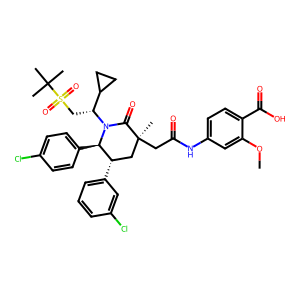

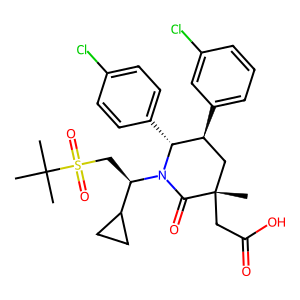

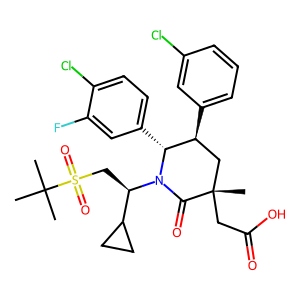

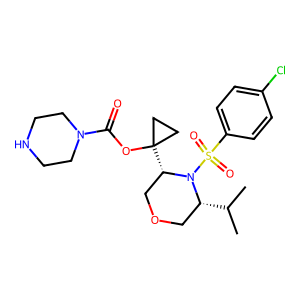

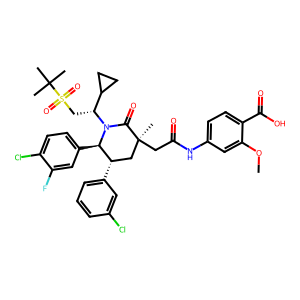

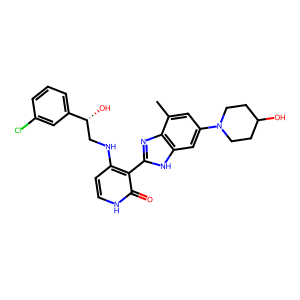

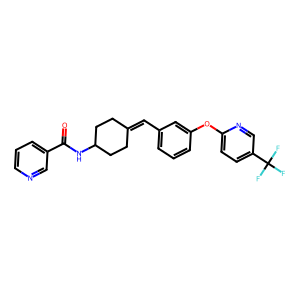

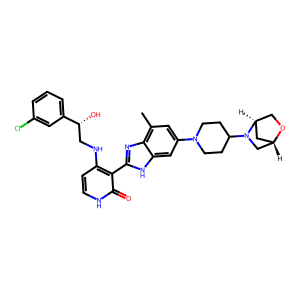

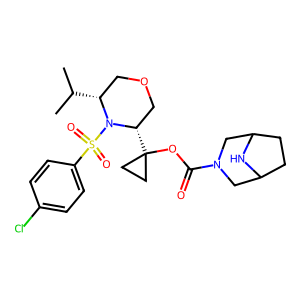

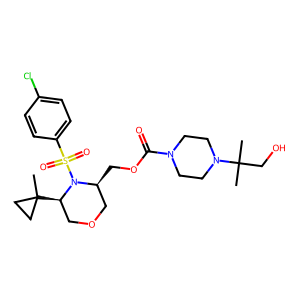

In [ ]:
top_molecules = resulting_training.sort_values(by="normalized_score", ascending=False)
for i in range(10):
  mol = Chem.MolFromSmiles(top_molecules["Canonical"].iloc[i])
  display(Draw.MolToImage(mol))

In [ ]:
grouped = df_filtered2.groupby(by="assay_chembl_id").apply(len).sort_values(ascending=False)
grouped2 = grouped[grouped >= 30]
print(grouped2)
assays_to_inspect = grouped2.index
print(assays_to_inspect)

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

sc_training = StandardScaler()
sc_arbitrary = StandardScaler()

df_train["normalized_score"] = sc_training.fit_transform(df_train["Inhibition"].values.reshape(-1, 1))
df_filtered2["normalized_score"] = sc_arbitrary.fit_transform(df_filtered2["pchembl_value"].values.reshape(-1, 1))

print(df_train.describe())
print(df_filtered2.describe())